# Disciplina: Aprendizado Não Supervisionado de Máquina
## Discente: Bruno Victor Paiva da Silva - 20261006269

**1)** Seja a v.a. $X$ definida como a soma de $n$ v.a. ($X = X_1, X_2, \dots, X_n$) uniformemente distribuídas entre 0 e 1. Desenvolva um programa para obtenha a média ($E[X]$), a variância ($\sigma^2[X]$), o segundo momento ($E[X^2]$). Gere os gráficos das funções densidade de probabilidade ($f_X(X)$) e distribuição de probabilidade ($F_X(X)$), para o caso de $n = 1, 2, \dots, 12$. Analise os resultados. Para qual distribuição a v.a. $X$ tende quando o valor de $n$ aumenta? Por que isto ocorre? Há uma expressão para a média e a variância em função de $n$?

- Sugestões: use tamanho de 10.000 amostras para gerar cada sequência de v.a.. Investigue o teorema do limite central.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

n   | E[X] teo/emp           | Var[X] teo/emp         | E[X²] teo/emp
1   | 0.5000 / 0.5000      | 0.0833 / 0.0831      | 0.3333 / 0.3331
2   | 1.0000 / 1.0064      | 0.1667 / 0.1658      | 1.1667 / 1.1786
3   | 1.5000 / 1.5022      | 0.2500 / 0.2489      | 2.5000 / 2.5055
4   | 2.0000 / 1.9973      | 0.3333 / 0.3316      | 4.3333 / 4.3209
5   | 2.5000 / 2.4995      | 0.4167 / 0.4244      | 6.6667 / 6.6720
6   | 3.0000 / 2.9962      | 0.5000 / 0.4953      | 9.5000 / 9.4726
7   | 3.5000 / 3.4914      | 0.5833 / 0.5901      | 12.8333 / 12.7800
8   | 4.0000 / 4.0085      | 0.6667 / 0.6577      | 16.6667 / 16.7259
9   | 4.5000 / 4.5093      | 0.7500 / 0.7527      | 21.0000 / 21.0863
10  | 5.0000 / 5.0072      | 0.8333 / 0.8482      | 25.8333 / 25.9207
11  | 5.5000 / 5.5032      | 0.9167 / 0.9143      | 31.1667 / 31.1996
12  | 6.0000 / 5.9894      | 1.0000 / 0.9989      | 37.0000 / 36.8718


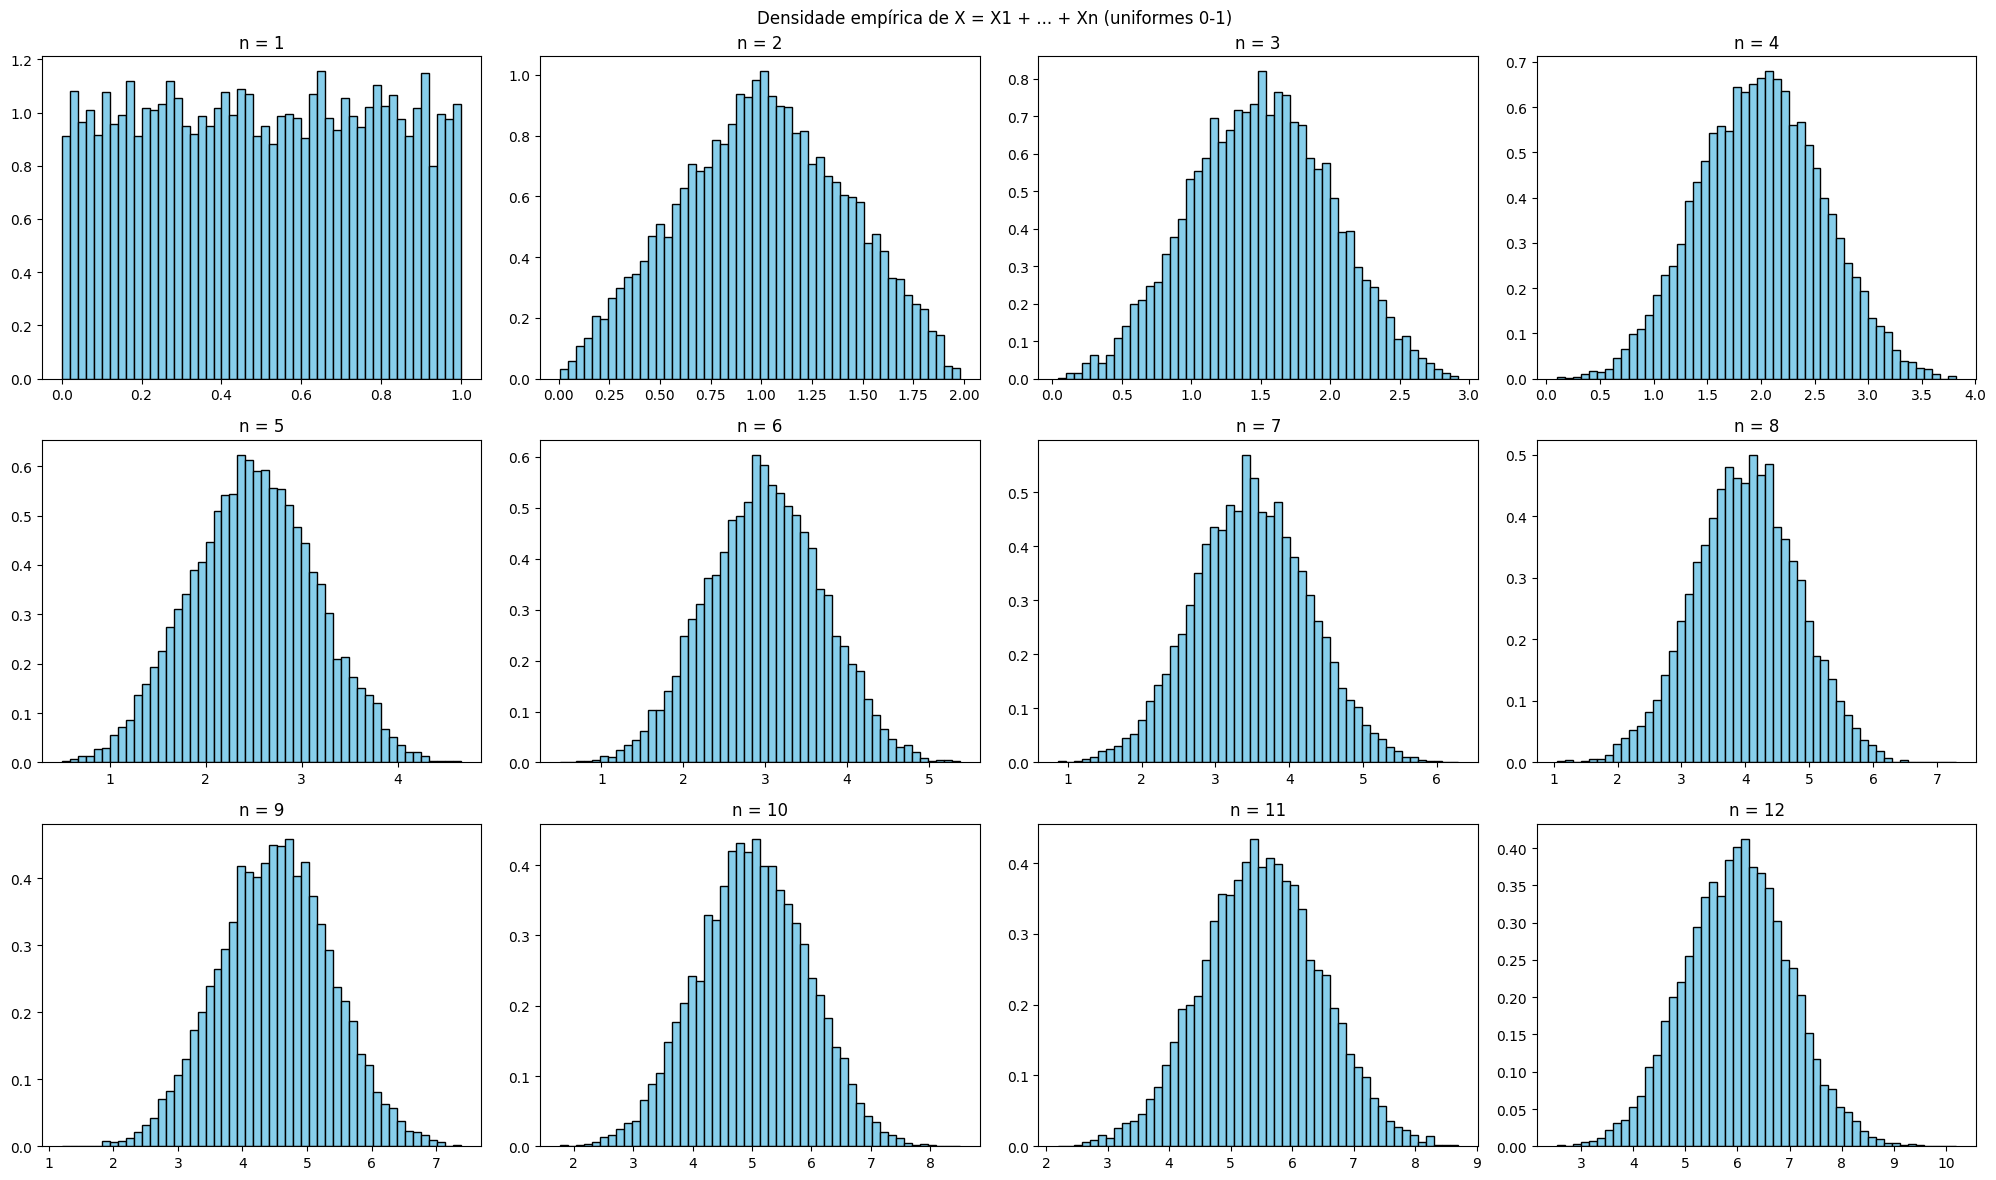

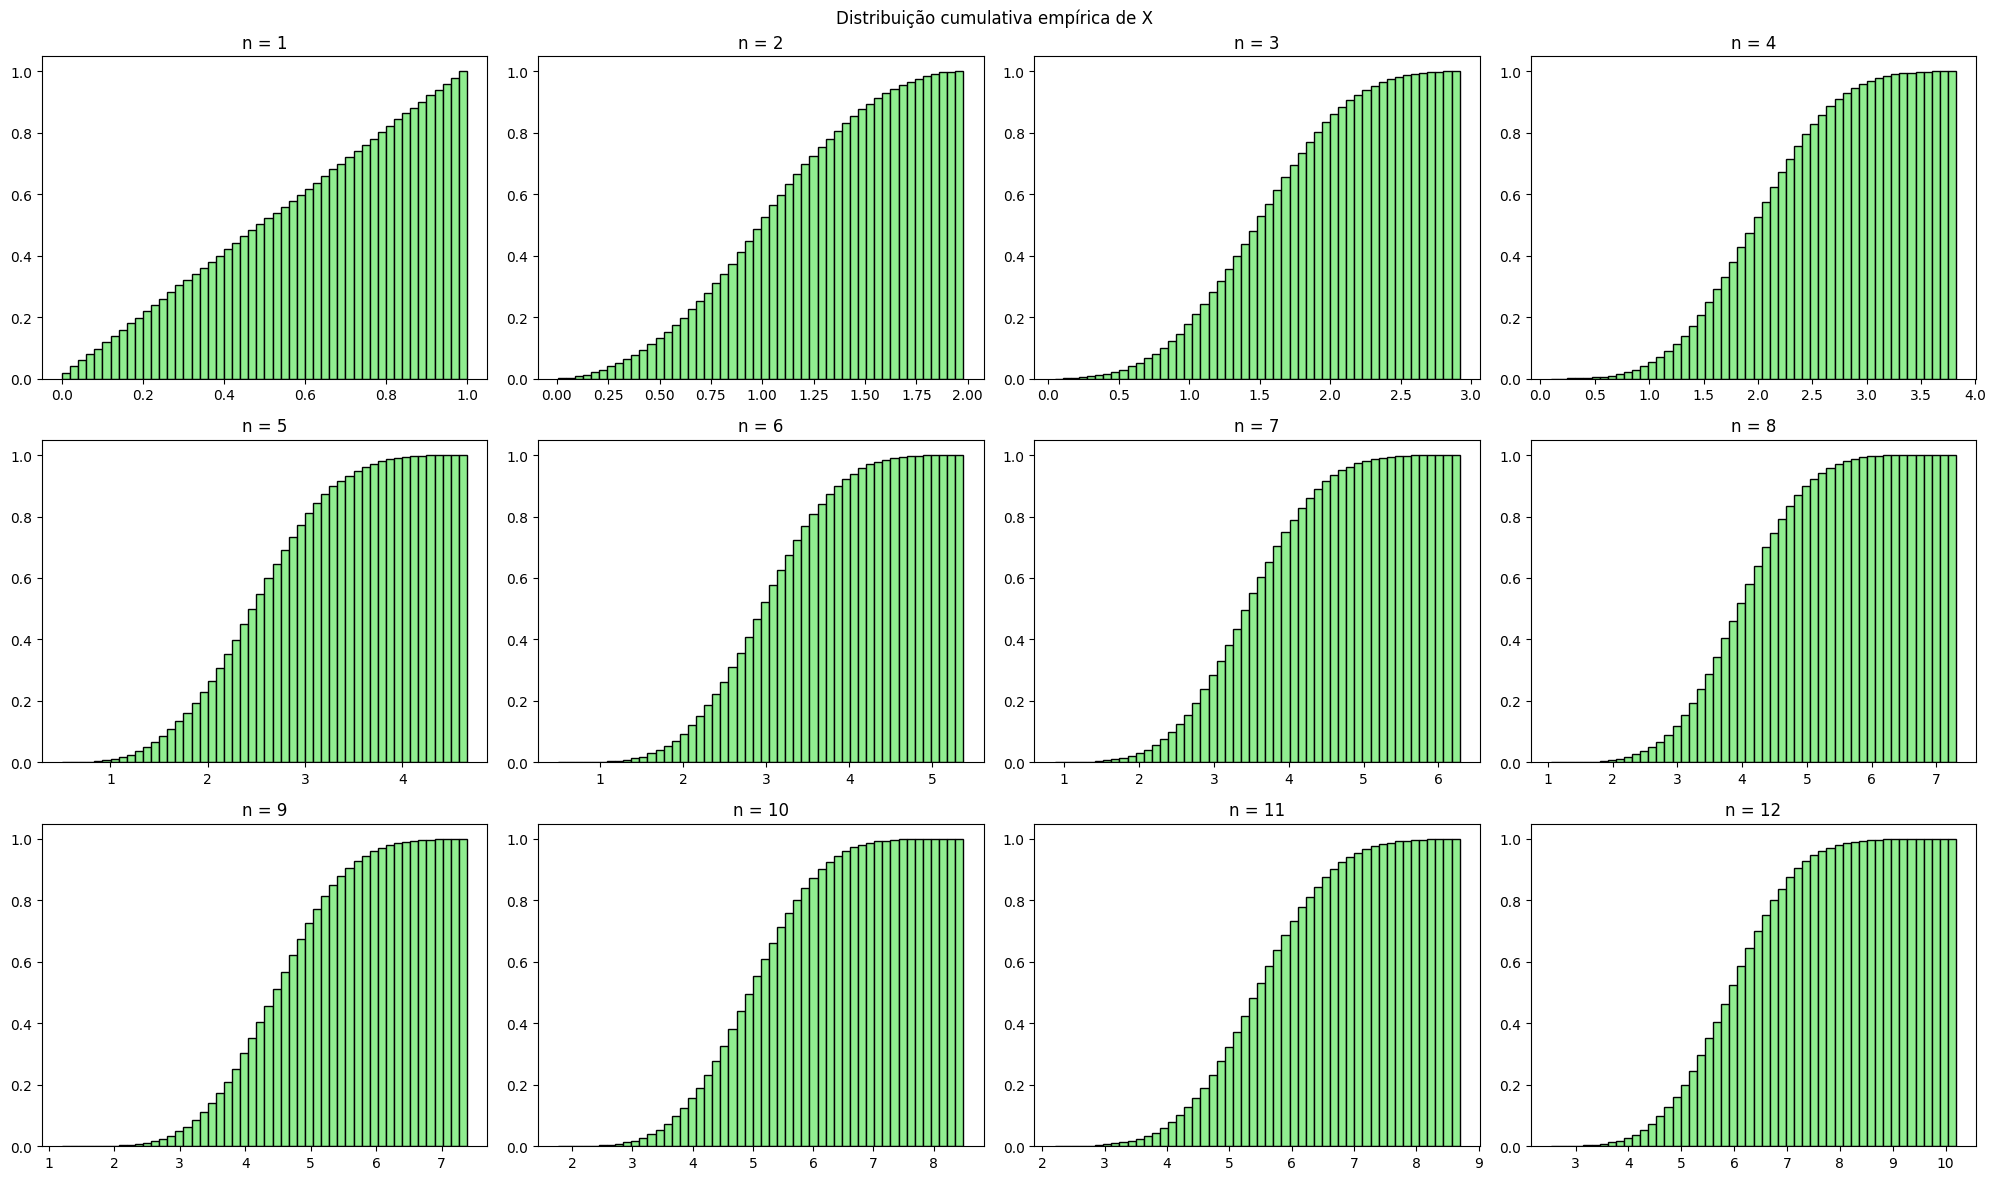

In [2]:
n_max = 12
amostras = 10000

fig_pdf, axs_pdf = plt.subplots(3, 4, figsize=(20, 12))
fig_cdf, axs_cdf = plt.subplots(3, 4, figsize=(20, 12))

print(f"{'n':<3} | {'E[X] teo/emp':<22} | {'Var[X] teo/emp':<22} | {'E[X²] teo/emp'}")

for i in range(1, n_max + 1):
    v_aleatorias = stats.uniform.rvs(loc=0, scale=1, size=(amostras, i))
    X = np.sum(v_aleatorias, axis=1)

    media_emp = np.mean(X)
    var_emp = np.var(X)
    momento2_emp = np.mean(X**2)

    media_teo = i / 2
    var_teo = i / 12
    momento2_teo = var_teo + media_teo**2

    print(f"{i:<3} | {media_teo:.4f} / {media_emp:.4f}      | {var_teo:.4f} / {var_emp:.4f}      | {momento2_teo:.4f} / {momento2_emp:.4f}")

    row, col = (i - 1) // 4, (i - 1) % 4

    axs_pdf[row, col].hist(X, bins=50, density=True, color='skyblue', edgecolor='black')
    axs_pdf[row, col].set_title(f'n = {i}')

    axs_cdf[row, col].hist(X, bins=50, density=True, cumulative=True, color='lightgreen', edgecolor='black')
    axs_cdf[row, col].set_title(f'n = {i}')

fig_pdf.suptitle('Densidade empírica de X = X1 + ... + Xn (uniformes 0-1)')
fig_cdf.suptitle('Distribuição cumulativa empírica de X')
fig_pdf.tight_layout()
fig_cdf.tight_layout()
plt.show()

Analise:

Para qual distribuição a v.a. $X$ tende quando o valor de n aumenta?

Inicialmente, A variável aleatória $X$ tende para uma Distribuição Normal (Gaussiana), podemos observar que nos gráficos de Densidade Empriríca, apartir do terceiro quadrante quando n = 3, a curva assimila a um formato de um sino.

A distribuição cumulativa acompanha essa tendência formando a curva sigmoide suave, ou seja, em formato de "S".

Por que isso ocorre?

Esse comportamento ocorre devido ao Teorema Central do Limite (TCL). Este teorema matemático estabelece que a soma de variáveis aleatórias independentes e identicamente distribuídas (i.i.d.), como é o caso das variáveis uniformes geradas no código, no qual se aproxima de uma distribuição normal à medida que o número de variáveis somadas aumenta.

Relação entre media e variancia:

A média é dada por:
$$E[X] = \frac{n}{2}$$

E a variância é:
$$Var(X) = \frac{n}{12}$$

O desvio padrão é:
$$\sigma_X = \sqrt{\frac{n}{12}}$$



2) Escreva um programa que dado $Y = aX^2 + b$, obtenha o histograma de $f(Y)$, sendo que $X$ é uma variável aleatória uniformemente distribuída entre 0 e 1. Teste o programa para as combinações de $a = 0, 0.5, 1, 2$ e $b = -1, 0, 1, 2, 4$ e compare com os respectivos $f(Y)$ teóricos. Analise como se comportam $E[X]$, $E[Y]$, $E[X^2]$, $E[Y^2]$, $Var(X)$, $Var(Y)$, $\sigma(X)$, $\sigma(Y)$, $Corr(X,Y)$ e $\rho(X,Y)$ em função dos valores de $a$ e $b$. Utilize ao menos 1.000 amostras para $X$.

a    | b   | E[Y]    | Var(Y)  | E[XY]   | Cov(X,Y)  | rho(X,Y)
-----------------------------------------------------------------
0    | -1  | -1.000  | 0.000   | -0.501  | 0.000     | 0.000  
0    | 0   | 0.000   | 0.000   | 0.000   | 0.000     | 0.000  
0    | 1   | 1.000   | 0.000   | 0.501   | 0.000     | 0.000  
0    | 2   | 2.000   | 0.000   | 1.001   | 0.000     | 0.000  
0    | 4   | 4.000   | 0.000   | 2.003   | 0.000     | 0.000  
0.5  | -1  | -0.833  | 0.022   | -0.376  | 0.041     | 0.968  
0.5  | 0   | 0.167   | 0.022   | 0.125   | 0.041     | 0.968  
0.5  | 1   | 1.167   | 0.022   | 0.626   | 0.041     | 0.968  
0.5  | 2   | 2.167   | 0.022   | 1.126   | 0.041     | 0.968  
0.5  | 4   | 4.167   | 0.022   | 2.128   | 0.041     | 0.968  
1    | -1  | -0.666  | 0.088   | -0.251  | 0.083     | 0.968  
1    | 0   | 0.334   | 0.088   | 0.250   | 0.083     | 0.968  
1    | 1   | 1.334   | 0.088   | 0.751   | 0.083     | 0.968  
1    | 2   | 2.334   | 0.088   | 1.251   | 0.083   

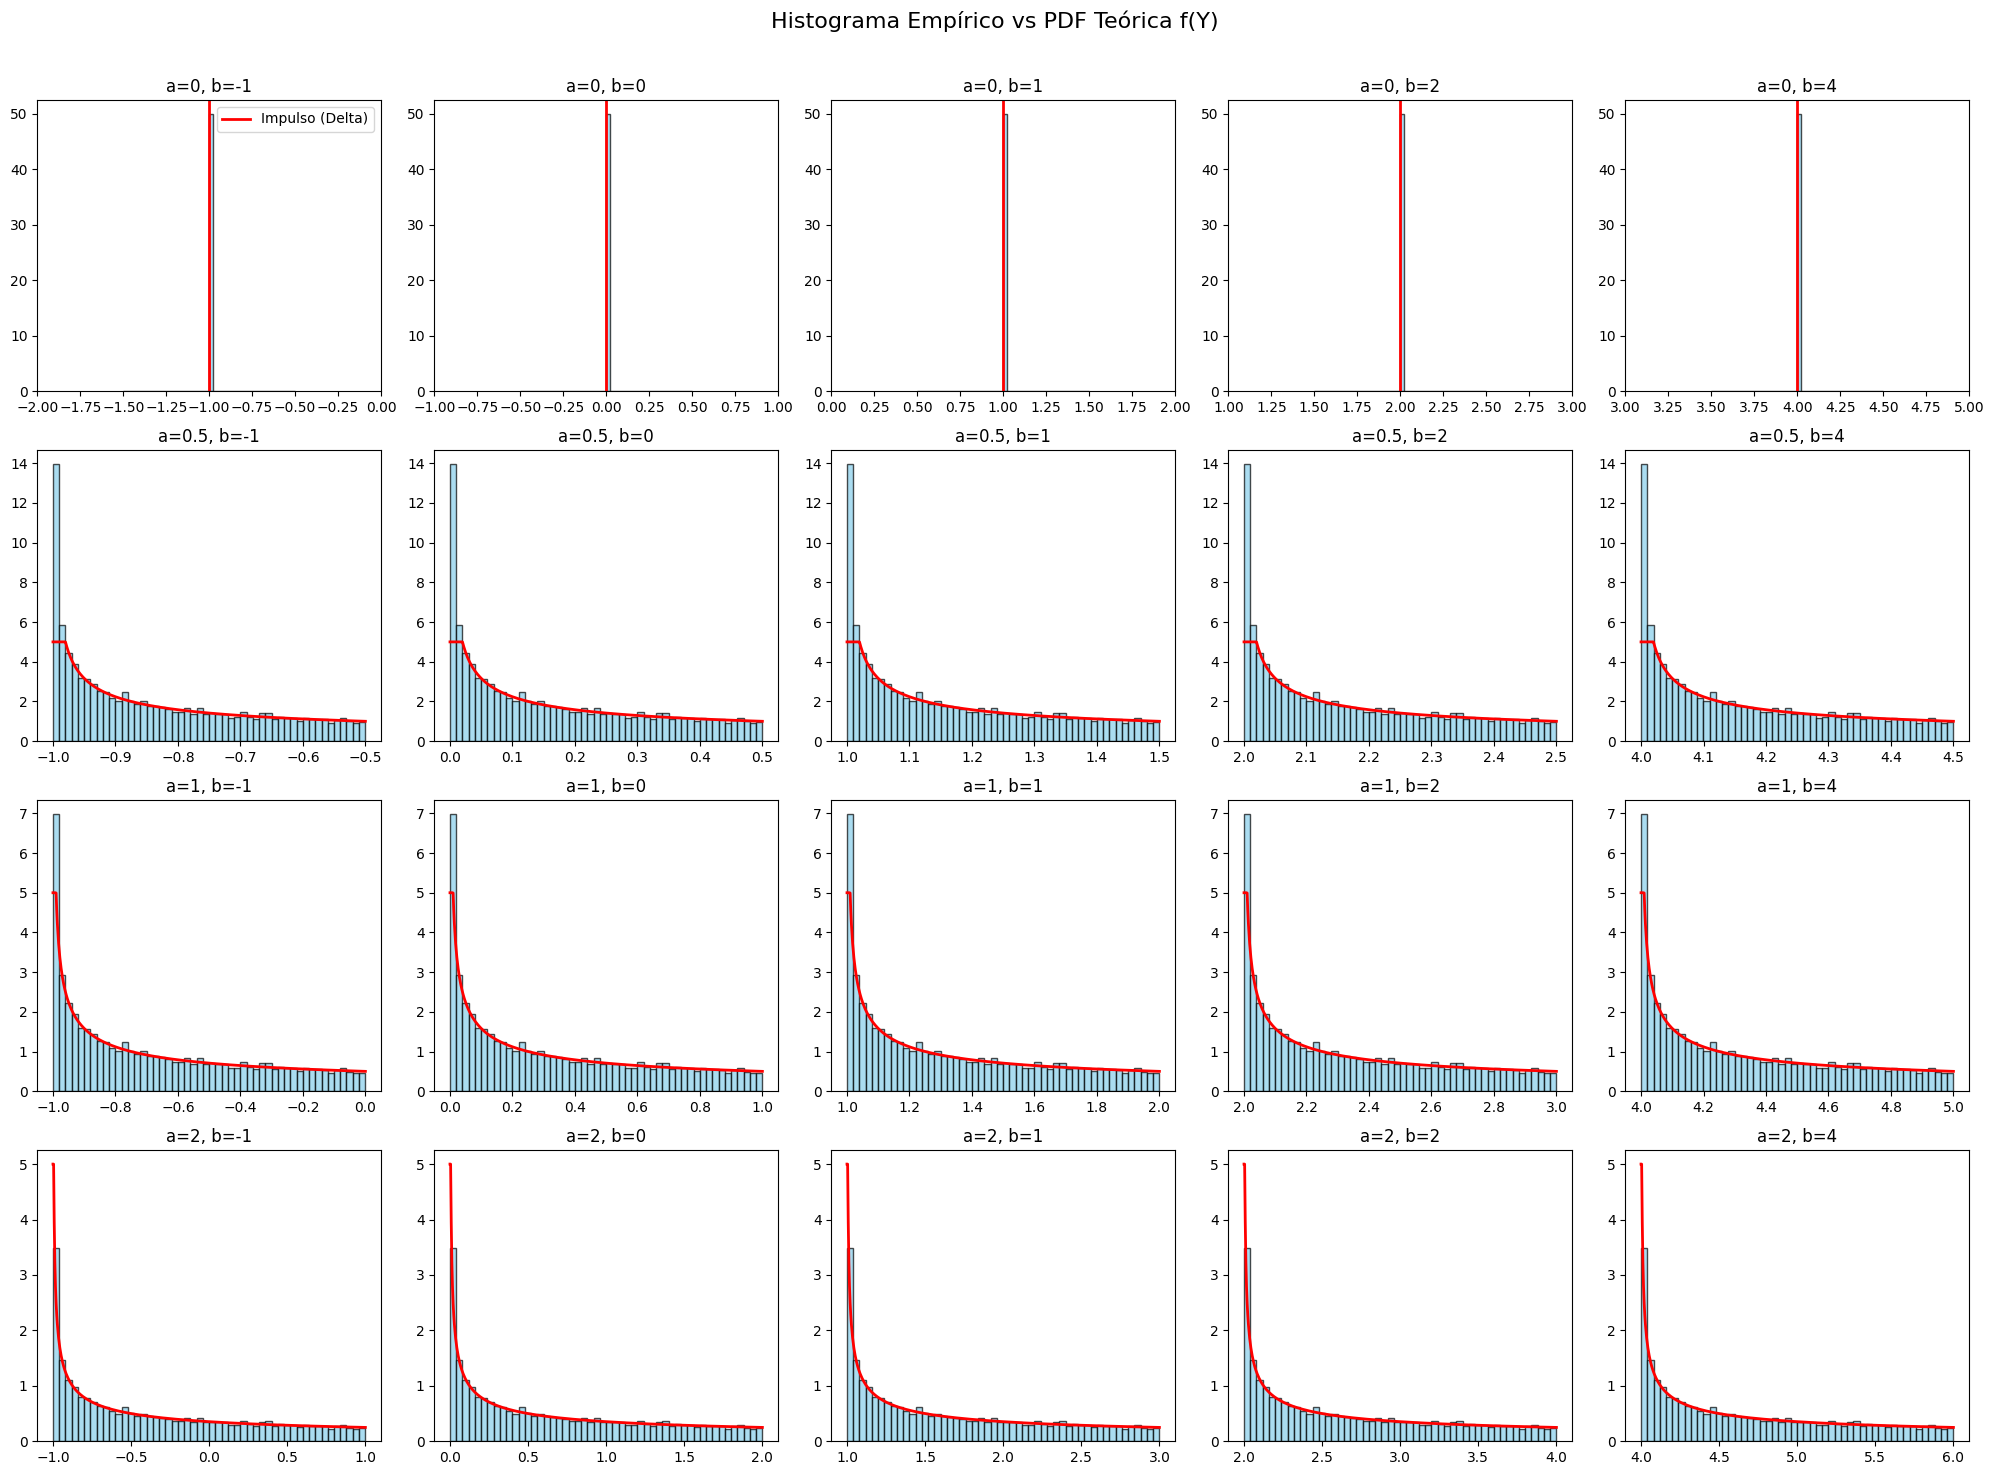

In [1]:
import numpy as np
import matplotlib.pyplot as plt

vetor_a = [0, 0.5, 1, 2]
vetor_b = [-1, 0, 1, 2, 4]
amostras = 10000

fig, axs = plt.subplots(len(vetor_a), len(vetor_b), figsize=(20, 15))
fig.suptitle('Histograma Empírico vs PDF Teórica f(Y)', fontsize=16)

X = np.random.uniform(0, 1, amostras)
E_X = np.mean(X)
E_X2 = np.mean(X**2)
Var_X = np.var(X)
std_X = np.std(X)

print(f"{'a':<4} | {'b':<3} | {'E[Y]':<7} | {'Var(Y)':<7} | {'E[XY]':<7} | {'Cov(X,Y)':<9} | {'rho(X,Y)':<7}")
print("-" * 65)

for i, a in enumerate(vetor_a):
    for j, b in enumerate(vetor_b):
        Y = a * X**2 + b
        
        E_Y = np.mean(Y)
        Var_Y = np.var(Y)
        E_XY = np.mean(X * Y)
        Cov_XY = np.cov(X, Y)[0, 1]
        
        if Var_Y > 1e-10:
            rho = Cov_XY / (std_X * np.std(Y))
        else:
            rho = 0.0
            
        print(f"{a:<4} | {b:<3} | {E_Y:<7.3f} | {Var_Y:<7.3f} | {E_XY:<7.3f} | {Cov_XY:<9.3f} | {rho:<7.3f}")

        ax = axs[i, j]
        
        ax.hist(Y, bins=50, density=True, color='skyblue', edgecolor='black', alpha=0.7)
        ax.set_title(f"a={a}, b={b}")
        
        if a > 0:
            y_teo = np.linspace(b + 1e-5, a + b, 500)
            f_y = 1 / (2 * np.sqrt(a * (y_teo - b)))
            
            f_y_clipped = np.clip(f_y, 0, 5) 
            ax.plot(y_teo, f_y_clipped, color='red', linewidth=2, label='f(Y) teórica')
        else:
            ax.axvline(x=b, color='red', linewidth=2, label='Impulso (Delta)')
            ax.set_xlim(b - 1, b + 1)
            
        if i == 0 and j == 0:
            ax.legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()